In [56]:
from pathlib import Path
import json
import sys

src_path = Path('../src').resolve()
sys.path.insert(0, str(src_path))
from pr_formatter import PRFormatter

formatter = PRFormatter()

## General Analysis - Gemini Flash Lite

In [57]:
def contar_arquivos(caminho):
    return sum(1 for item in Path(caminho).iterdir() if item.is_file())

pasta = Path('../django')
print(f"{contar_arquivos(pasta)} arquivos encontrados.")

18524 arquivos encontrados.


In [77]:
with open("../data/output_gemini_flash_lite_improve.json", "r", encoding="utf-8") as f:
    data = json.load(f)
    print(f"{len(data)} arquivos totais processados.")

count_empty_responses = sum(1 for item in data if item.get('issues') == [])  
count_issues_responses = len(data) - count_empty_responses
print(f"{count_empty_responses} arquivos com resposta vazia.")
print(f"{count_issues_responses} arquivos com issues identificadas.")

18629 arquivos totais processados.
17850 arquivos com resposta vazia.
779 arquivos com issues identificadas.


In [78]:
categorias_count = {
    "Broken Access Control": 0,
    "Cryptographic Failures": 0,
    "Injection": 0,
    "Insecure Design": 0,
    "Security Misconfiguration": 0,
    "Vulnerable and Outdated Components": 0,
    "Identification and Authentication": 0,
    "Software and Data Integrity Failures": 0,
    "Security Logging and Monitoring Failures": 0,
    "Server-Side Request Forgery": 0
}

other_categories = {}

for item in data:
    issues = item.get('issues', [])
    if type(issues) is dict:
        issues = [issues]
    
    if issues:
        for issue in issues:
            if type(issue) is not dict:
                print(f"Resposta inesperada {type(issue)} para issue: {issue}")
                continue
            categoria = issue.get('category')
            if categoria in categorias_count:
                categorias_count[categoria] += 1
            else:
                if categoria in other_categories:
                    other_categories[categoria] += 1
                else:
                    other_categories[categoria] = 1

print("Contagem por categoria:")
for categoria, count in categorias_count.items():
    print(f"{categoria}: {count}")

Contagem por categoria:
Broken Access Control: 31
Cryptographic Failures: 60
Injection: 51
Insecure Design: 50
Security Misconfiguration: 475
Vulnerable and Outdated Components: 66
Identification and Authentication: 24
Software and Data Integrity Failures: 59
Security Logging and Monitoring Failures: 32
Server-Side Request Forgery: 0


In [79]:
# Category names that were not in the predefined list
if other_categories:
    print("\nCategorias adicionais encontradas:")
    for categoria, count in other_categories.items():
        print(f"{categoria}: {count}")

In [75]:
# Pega IDs dos PRs que tiveram categorias fora do esperado
ids_categorias_fora = []
for item in data:
    issues = item.get('issues', [])
    if type(issues) is dict:
        issues = [issues]
    
    for issue in issues:
        if type(issue) is not dict:
            continue
        categoria = issue.get('category')
        if categoria not in categorias_count:
            ids_categorias_fora.append(item.get('id'))
print(f"\nIDs dos PRs com categorias fora do esperado: {ids_categorias_fora}")



IDs dos PRs com categorias fora do esperado: ['MDExOlB1bGxSZXF1ZXN0MjcwMjQzMDM4', 'MDExOlB1bGxSZXF1ZXN0MzMyODg2NTY=']


In [76]:
str(ids_categorias_fora).replace("'", "").replace("[", "").replace("]", "").replace(" ", "")

'MDExOlB1bGxSZXF1ZXN0MjcwMjQzMDM4,MDExOlB1bGxSZXF1ZXN0MzMyODg2NTY='

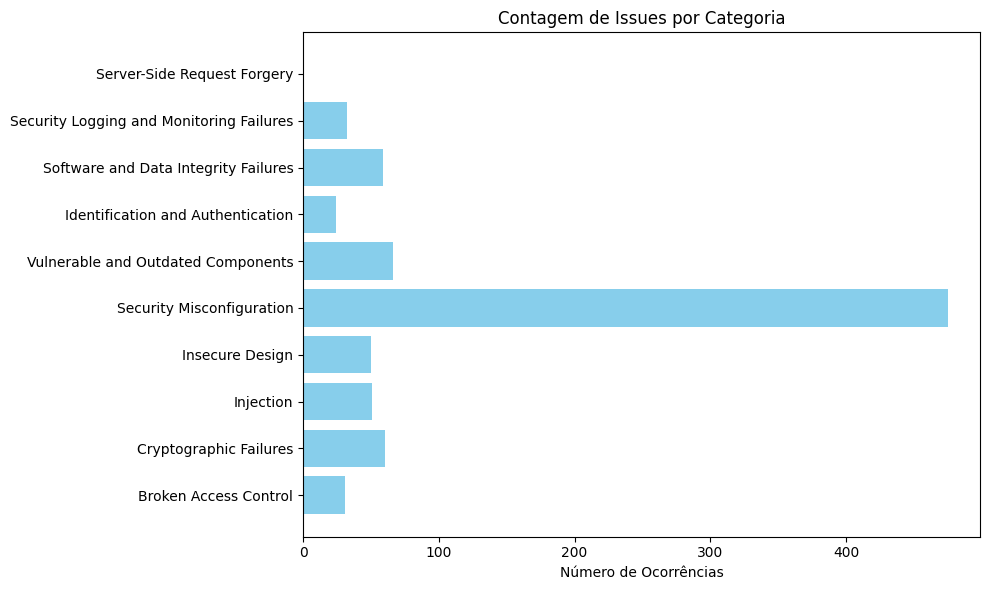

In [80]:
import matplotlib.pyplot as plt
labels = list(categorias_count.keys())
values = list(categorias_count.values())
plt.figure(figsize=(10,6))
plt.barh(labels, values, color='skyblue')
plt.xlabel('Número de Ocorrências')
plt.title('Contagem de Issues por Categoria')
plt.tight_layout()
plt.show()

In [81]:
from datetime import datetime

def gerar_documento_markdown(output_path='../category_examples_analysis.md'):
    """
    Gera um documento markdown com um exemplo de PR para cada categoria OWASP.
    
    Args:
        output_path: Caminho do arquivo markdown a ser gerado
    """
    with open(output_path, 'w', encoding='utf-8') as md_file:
        # Cabeçalho do documento
        md_file.write('# Análise de Categorias OWASP - Exemplos por Categoria\n\n')
        md_file.write('Este documento contém um exemplo de Pull Request para cada categoria OWASP identificada.\n\n')
        md_file.write(f'**Data de geração:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n')
        md_file.write('---\n\n')
        
        # Para cada categoria, buscar um exemplo
        for categoria in categorias_count.keys():
            md_file.write(f'## {categoria}\n\n')
            
            exemplo_encontrado = False
            
            for item in data:
                issues = item.get('issues', [])
                if type(issues) is dict:
                    issues = [issues]
                
                for issue in issues:
                    if type(issue) is not dict:
                        continue
                    
                    if issue.get('category') == categoria:
                        try:
                            # Obter conteúdo formatado do PR
                            formated_pr = formatter.format_pr_discussions(file_path=f"../django/{item['id']}.json")
                            
                            # Escrever informações no markdown
                            md_file.write(f'### PR ID: `{item["id"]}`\n\n')
                            md_file.write('#### Conteúdo do Pull Request\n\n')
                            md_file.write('```\n')
                            md_file.write(str(formated_pr))
                            md_file.write('\n```\n\n')
                            md_file.write('#### Análise do Modelo\n\n')
                            md_file.write(f'**Issue identificada:** {issue.get("issue", "N/A")}\n\n')
                            md_file.write(f'**Categoria:** {issue.get("category", "N/A")}\n\n')
                            
                            if 'severity' in issue:
                                md_file.write(f'**Severidade:** {issue.get("severity")}\n\n')
                            
                            md_file.write('---\n\n')
                            
                            exemplo_encontrado = True
                            break
                        except Exception as e:
                            print(f"Erro ao processar {item['id']}: {e}")
                            continue
                
                if exemplo_encontrado:
                    break
            
            if not exemplo_encontrado:
                md_file.write('*Nenhum exemplo encontrado para esta categoria.*\n\n')
                md_file.write('---\n\n')
    
    print(f"Documento markdown gerado com sucesso: {output_path}")
    return output_path

# Criar documento com esses dados
gerar_documento_markdown()



Documento markdown gerado com sucesso: ../category_examples_analysis.md


'../category_examples_analysis.md'

## Geração de Planilha Excel para Avaliação

Vamos criar uma planilha Excel com 5% dos PRs de cada categoria para avaliação manual.

In [83]:
import pandas as pd
import random
import math
from datetime import datetime

# Definir seed para reprodutibilidade
random.seed(42)

In [84]:
def get_prs_by_category(category_name):
    """Retorna lista de IDs de PRs para uma categoria específica"""
    prs = []
    for item in data:
        issues = item.get('issues', [])
        if type(issues) is dict:
            issues = [issues]
        if issues:
            for issue in issues:
                categoria = issue.get('category')
                if categoria == category_name:
                    prs.append({
                        'id': item['id'],
                        'issue_data': issue
                    })
                    break  # Evitar duplicatas se houver múltiplas issues da mesma categoria
    return prs

In [85]:
def get_pr_formatted_data(pr_id):
    """Retorna dados formatados do PR e saída da LLM"""
    try:
        # Obter dados formatados
        file_path = Path('../django') / f"{pr_id}.json"
        if file_path.exists():
            formatted_pr = formatter.format_pr_discussions(file_path)
        else:
            formatted_pr = f"Arquivo não encontrado: {file_path}"
        
        # Obter saída da LLM
        llm_output = None
        for item in data:
            if item.get('id') == pr_id:
                llm_output = item
                break
        
        return formatted_pr, llm_output
    except Exception as e:
        return f"Erro ao processar {pr_id}: {str(e)}", None

In [86]:
# Coletar dados para Excel
excel_data = []

print("Coletando amostras por categoria:")
print("=" * 50)

for categoria in categorias_count.keys():
    count = categorias_count[categoria]
    if count > 0:
        # Obter todos os PRs da categoria
        prs_categoria = get_prs_by_category(categoria)
        
        # Calcular 5% (mínimo 1, máximo disponível)
        sample_size = max(1, math.ceil(count * 0.05))
        sample_size = min(sample_size, len(prs_categoria))
        
        # Selecionar amostra aleatória
        sample_prs = random.sample(prs_categoria, sample_size)
        
        print(f"{categoria}: {count} total → {sample_size} selecionados")
        
        # Processar cada PR da amostra
        for pr_data in sample_prs:
            pr_id = pr_data['id']
            issue_data = pr_data['issue_data']
            
            # Obter dados formatados
            formatted_pr, llm_output = get_pr_formatted_data(pr_id)
            
            # Adicionar à lista para Excel
            excel_data.append({
                'PR_ID': pr_id,
                'PR_Formatted': str(formatted_pr)[:2000] + '...' if len(str(formatted_pr)) > 2000 else str(formatted_pr),
                'LLM_Output': str(llm_output)[:1000] + '...' if len(str(llm_output)) > 1000 else str(llm_output),
                'Category': categoria,
                'Issue_Description': issue_data.get('issue', ''),
                'Evaluation': '',  # Vazio para preenchimento manual
                'Justify': ''      # Vazio para preenchimento manual
            })

print(f"\nTotal de registros coletados: {len(excel_data)}")

Coletando amostras por categoria:
Broken Access Control: 31 total → 2 selecionados
Cryptographic Failures: 60 total → 3 selecionados
Injection: 51 total → 3 selecionados
Insecure Design: 50 total → 3 selecionados
Security Misconfiguration: 475 total → 24 selecionados
Vulnerable and Outdated Components: 66 total → 4 selecionados
Identification and Authentication: 24 total → 2 selecionados
Software and Data Integrity Failures: 59 total → 3 selecionados
Security Logging and Monitoring Failures: 32 total → 2 selecionados

Total de registros coletados: 46


In [87]:
# Criar DataFrame
df = pd.DataFrame(excel_data)

# Reordenar colunas
column_order = ['PR_ID', 'Category', 'Issue_Description', 'PR_Formatted', 'LLL_Output', 'Evaluation', 'Justify']
df = df[['PR_ID', 'Category', 'Issue_Description', 'PR_Formatted', 'LLM_Output', 'Evaluation', 'Justify']]

# Salvar Excel
output_file = '../evaluation_sample.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='PR_Evaluation', index=False)
    
    # Ajustar largura das colunas
    worksheet = writer.sheets['PR_Evaluation']
    
    # Definir larguras das colunas
    column_widths = {
        'A': 30,  # PR_ID
        'B': 25,  # Category 
        'C': 40,  # Issue_Description
        'D': 80,  # PR_Formatted
        'E': 60,  # LLM_Output
        'F': 15,  # Evaluation
        'G': 40   # Justify
    }
    
    for col, width in column_widths.items():
        worksheet.column_dimensions[col].width = width
        
    # Configurar quebra de texto
    from openpyxl.styles import Alignment
    
    for row in worksheet.iter_rows(min_row=2):  # Pular cabeçalho
        for cell in row:
            if cell.column_letter in ['C', 'D', 'E', 'G']:  # Colunas com texto longo
                cell.alignment = Alignment(wrap_text=True, vertical='top')

print(f"Planilha Excel criada: {output_file}")
print(f"Total de registros: {len(df)}")
print("\nDistribuição por categoria:")
print(df['Category'].value_counts().sort_index())

Planilha Excel criada: ../evaluation_sample.xlsx
Total de registros: 46

Distribuição por categoria:
Category
Broken Access Control                        2
Cryptographic Failures                       3
Identification and Authentication            2
Injection                                    3
Insecure Design                              3
Security Logging and Monitoring Failures     2
Security Misconfiguration                   24
Software and Data Integrity Failures         3
Vulnerable and Outdated Components           4
Name: count, dtype: int64


In [36]:
# Mostrar primeiras linhas como preview
print("Preview dos dados coletados:")
print("=" * 80)

for i, row in df.head(3).iterrows():
    print(f"\n{i+1}. PR: {row['PR_ID']}")
    print(f"   Categoria: {row['Category']}")
    print(f"   Issue: {row['Issue_Description'][:100]}...")
    print(f"   PR Formatado: {str(row['PR_Formatted'])[:150]}...")
    print(f"   LLM Output: {str(row['LLM_Output'])[:100]}...")
    print("-" * 80)

Preview dos dados coletados:

1. PR: MDExOlB1bGxSZXF1ZXN0NTU0Nzg3NDE=
   Categoria: Broken Access Control
   Issue: ...
   PR Formatado: {'pr': {'title': 'Fixed #21608 -- Prevented logged out sessions being resurrected by concurrent requests.', 'id': 'MDExOlB1bGxSZXF1ZXN0NTU0Nzg3NDE=', ...
   LLM Output: {'id': 'MDExOlB1bGxSZXF1ZXN0NTU0Nzg3NDE=', 'issues': [{'category': 'Broken Access Control', 'descrip...
--------------------------------------------------------------------------------

2. PR: MDExOlB1bGxSZXF1ZXN0NDMzNjcxODk=
   Categoria: Broken Access Control
   Issue: ...
   PR Formatado: {'pr': {'title': 'Fixed #12405 -- Added settings.LOGOUT_REDIRECT_URL.', 'id': 'MDExOlB1bGxSZXF1ZXN0NDMzNjcxODk=', 'description': 'After a user logs ou...
   LLM Output: {'id': 'MDExOlB1bGxSZXF1ZXN0NDMzNjcxODk=', 'issues': [{'category': 'Broken Access Control', 'descrip...
--------------------------------------------------------------------------------

3. PR: PR_kwDOAD-Lgs4_Iwhd
   Categoria: Broke